## **Importing Libraries**

In [1]:
# Importing Libraries
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, PandasTools, AllChem

import mordred
from mordred import Calculator, descriptors


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

pd.set_option('display.max_columns', 2000)
warnings.filterwarnings("ignore")

In [3]:
sns.set(style='whitegrid')

In [4]:
data = pd.read_csv(r'C:\Users\pc\Desktop\project\tutorial_rdkit\delaney.csv')
data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl


In [5]:
mol_list = []

for smile in data['SMILES']:
  mol = Chem.MolFromSmiles(smile)
  mol = Chem.AddHs(mol)
  AllChem.EmbedMolecule(mol)
  mol_list.append(mol)

data = pd.concat([data, pd.DataFrame(mol_list, columns = (['Mol']))], axis=1)

In [6]:
data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001F5F5D...
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001F5F5D...
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001F5F5D...
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001F5F5D...
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001F5F5D...


In [7]:
mol = data['Mol'][54]

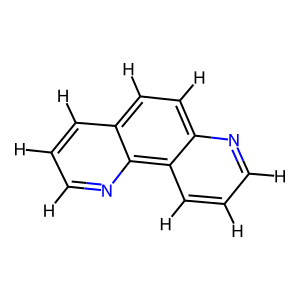

In [8]:
img = Draw.MolToImage(mol)
img

tsayft: mols_grid.svg


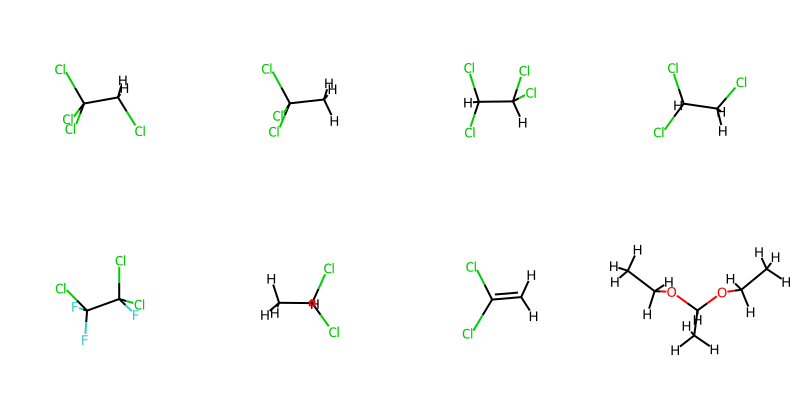

In [9]:
mols_to_draw = data['Mol'].tolist()[:8]
svg = Draw.MolsToGridImage(
    mols_to_draw,
    molsPerRow=4,
    subImgSize=(200, 200),
    useSVG=True
)
svg_text = svg.data if hasattr(svg, 'data') else svg
with open("mols_grid.svg", "w") as f:
    f.write(svg_text)

print("tsayft: mols_grid.svg")
svg  

In [10]:
# Creating a descriptor calculator with all descriptors
calc = Calculator(descriptors, ignore_3D=False)

all_desc = calc.pandas(data['Mol'])

100%|██████████| 1144/1144 [02:48<00:00,  6.80it/s]


In [11]:
all_desc.head()

ABC     ABCGG  nAcid  nBase   SpAbs_A   SpMax_A  SpDiam_A    SpAD_A  \
0  4.012290  4.284816      0      0  5.818626  2.074313  4.148627  5.818626   
1  3.464102  3.464102      0      0  4.000000  2.000000  4.000000  4.000000   
2  3.932653  4.244375      0      0  6.000000  2.000000  4.000000  6.000000   
3  3.047207  3.305183      0      0  5.226252  1.847759  3.695518  5.226252   
4  5.808525  6.167293      0      0  7.211103  2.302776  4.605551  7.211103   

    SpMAD_A   LogEE_A     VE1_A     VE2_A     VE3_A      VR1_A     VR2_A  \
0  0.969771  2.626363  2.285500  0.380917  0.315759  11.637367  1.939561   
1  0.800000  2.444466  2.121320  0.424264  0.058892   8.000000  1.600000   
2  1.000000  2.610845  2.309401  0.384900  0.326163  11.530010  1.921668   
3  1.045250  2.408576  2.130986  0.426197  0.063438   8.629874  1.725975   
4  0.901388  2.947233  2.602595  0.325324  0.733365  17.881697  2.235212   

      VR3_A  nAromAtom  nAromBond  nAtom  nHeavyAtom  nSpiro  nBridgehead  \
0  1.943396          0          0      8           6       0            0   
1  1.386294          0          0      8           5       0            0   
2  1.934128          0          0      8           6       0            0   
3  1.462083          0          0      8           5       0            0   
4  2.660634          0          0      8           8       0            0   

   nHetero  nH  nB  nC  nN  nO  nS  nP  nF  nCl  nBr  nI  nX      ATS0dv  \
0        4   2   0   2   0   0   0   0   0    4    0   0   4   22.419753   
1        3   3   0   2   0   0   0   0   0    3    0   0   3   18.814815   
2        4   2   0   2   0   0   0   0   0    4    0   0   4   20.419753   
3        3   3   0   2   0   0   0   0   0    3    0   0   3   14.814815   
4        6   0   0   2   0   0   0   0   3    3    0   0   6  180.814815   

       ATS1dv      ATS2dv      ATS3dv  ATS4dv  ATS5dv  ATS6dv  ATS7dv  ATS8dv  \
0   18.888889    9.592593    1.814815     0.0     0.0     0.0     0.0     0.0   
1   13.333333    4.148148    0.000000     0.0     0.0     0.0     0.0     0.0   
2   18.333333   10.543210    2.419753     0.0     0.0     0.0     0.0     0.0   
3   12.222222    6.049383    1.209877     0.0     0.0     0.0     0.0     0.0   
4  109.333333  164.716049  126.432099     0.0     0.0     0.0     0.0     0.0   

   ATS0d  ATS1d  ATS2d  ATS3d  ATS4d  ATS5d  ATS6d  ATS7d  ATS8d       ATS0s  \
0   26.0   26.0   24.0    9.0    0.0    0.0    0.0    0.0    0.0   13.055908   
1   23.0   19.0   21.0    9.0    0.0    0.0    0.0    0.0    0.0   13.995056   
2   24.0   27.0   24.0    9.0    0.0    0.0    0.0    0.0    0.0   12.798964   
3   19.0   21.0   21.0    9.0    0.0    0.0    0.0    0.0    0.0   12.460334   
4   38.0   40.0   30.0    9.0    0.0    0.0    0.0    0.0    0.0  200.557556   

       ATS1s       ATS2s       ATS3s ATS4s ATS5s ATS6s ATS7s ATS8s   ATS0Z  \
0  11.939815   19.361568    13.50663   0.0   0.0   0.0   0.0   0.0  1230.0   
1  13.546296    20.25663   12.111111   0.0   0.0   0.0   0.0   0.0   942.0   
2  11.621399   18.848041   13.626124   0.0   0.0   0.0   0.0   0.0  1230.0   
3  11.940329    18.19151   12.350099   0.0   0.0   0.0   0.0   0.0   942.0   
4  36.608796  143.918877  185.448865   0.0   0.0   0.0   0.0   0.0  1182.0   

   ATS1Z   ATS2Z   ATS3Z  ATS4Z  ATS5Z  ATS6Z  ATS7Z  ATS8Z        ATS0m  \
0  456.0  1322.0   969.0    0.0    0.0    0.0    0.0    0.0  5317.370370   
1  360.0  1194.0   153.0    0.0    0.0    0.0    0.0    0.0  4061.683934   
2  456.0  1066.0  1225.0    0.0    0.0    0.0    0.0    0.0  5317.370370   
3  360.0   682.0   665.0    0.0    0.0    0.0    0.0    0.0  4061.683934   
4  504.0  1450.0  1505.0    0.0    0.0    0.0    0.0    0.0  5141.453714   

         ATS1m        ATS2m        ATS3m  ATS4m  ATS5m  ATS6m  ATS7m  ATS8m  \
0  1871.638097  5569.964740  3984.509100    0.0    0.0    0.0    0.0    0.0   
1  1457.955235  5086.846806   321.602400    0.0    0.0    0.0    0.0    0.0   
2  1871.638097  4383.7133

In [12]:
all_desc.shape

(1144, 1826)

In [ ]:
data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001F5F5D...
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001F5F5D...
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001F5F5D...
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001F5F5D...
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001F5F5D...


In [ ]:
df_index = data[['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']]

In [15]:
df = pd.concat([df_index, all_desc], axis=1)
df.head()

Compound ID               SMILES  \
0       1,1,1,2-Tetrachloroethane       ClCC(Cl)(Cl)Cl   
1           1,1,1-Trichloroethane         CC(Cl)(Cl)Cl   
2       1,1,2,2-Tetrachloroethane       ClC(Cl)C(Cl)Cl   
3           1,1,2-Trichloroethane           ClCC(Cl)Cl   
4  1,1,2-Trichlorotrifluoroethane  FC(F)(Cl)C(F)(Cl)Cl   

   measured log(solubility:mol/L)       ABC     ABCGG  nAcid  nBase   SpAbs_A  \
0                           -2.18  4.012290  4.284816      0      0  5.818626   
1                           -2.00  3.464102  3.464102      0      0  4.000000   
2                           -1.74  3.932653  4.244375      0      0  6.000000   
3                           -1.48  3.047207  3.305183      0      0  5.226252   
4                           -3.04  5.808525  6.167293      0      0  7.211103   

    SpMax_A  SpDiam_A    SpAD_A   SpMAD_A   LogEE_A     VE1_A     VE2_A  \
0  2.074313  4.148627  5.818626  0.969771  2.626363  2.285500  0.380917   
1  2.000000  4.000000  4.000000  0.800000  2.444466  2.121320  0.424264   
2  2.000000  4.000000  6.000000  1.000000  2.610845  2.309401  0.384900   
3  1.847759  3.695518  5.226252  1.045250  2.408576  2.130986  0.426197   
4  2.302776  4.605551  7.211103  0.901388  2.947233  2.602595  0.325324   

      VE3_A      VR1_A     VR2_A     VR3_A  nAromAtom  nAromBond  nAtom  \
0  0.315759  11.637367  1.939561  1.943396          0          0      8   
1  0.058892   8.000000  1.600000  1.386294          0          0      8   
2  0.326163  11.530010  1.921668  1.934128          0          0      8   
3  0.063438   8.629874  1.725975  1.462083          0          0      8   
4  0.733365  17.881697  2.235212  2.660634          0          0      8   

   nHeavyAtom  nSpiro  nBridgehead  nHetero  nH  nB  nC  nN  nO  nS  nP  nF  \
0           6       0            0        4   2   0   2   0   0   0   0   0   
1           5       0            0        3   3   0   2   0   0   0   0   0   
2           6       0            0        4   2   0   2   0   0   0   0   0   
3           5       0            0        3   3   0   2   0   0   0   0   0   
4           8       0            0        6   0   0   2   0   0   0   0   3   

   nCl  nBr  nI  nX      ATS0dv      ATS1dv      ATS2dv      ATS3dv  ATS4dv  \
0    4    0   0   4   22.419753   18.888889    9.592593    1.814815     0.0   
1    3    0   0   3   18.814815   13.333333    4.148148    0.000000     0.0   
2    4    0   0   4   20.419753   18.333333   10.543210    2.419753     0.0   
3    3    0   0   3   14.814815   12.222222    6.049383    1.209877     0.0   
4    3    0   0   6  180.814815  109.333333  164.716049  126.432099     0.0   

   ATS5dv  ATS6dv  ATS7dv  ATS8dv  ATS0d  ATS1d  ATS2d  ATS3d  ATS4d  ATS5d  \
0     0.0     0.0     0.0     0.0   26.0   26.0   24.0    9.0    0.0    0.0   
1     0.0     0.0     0.0     0.0   23.0   19.0   21.0    9.0    0.0    0.0   
2     0.0     0.0     0.0     0.0   24.0   27.0   24.0    9.0    0.0    0.0   
3     0.0     0.0     0.0     0.0   19.0   21.0   21.0    9.0    0.0    0.0   
4     0.0     0.0     0.0     0.0   38.0   40.0   30.0    9.0    0.0    0.0   

   ATS6d  ATS7d  ATS8d       ATS0s      ATS1s       ATS2s       ATS3s ATS4s  \
0    0.0    0.0    0.0   13.055908  11.939815   19.361568    13.50663   0.0   
1    0.0    0.0    0.0   13.995056  13.546296    20.25663   12.111111   0.0   
2    0.0    0.0    0.0   12.798964  11.621399   18.848041   13.626124   0.0   
3    0.0    0.0    0.0   12.460334  11.940329    18.19151   12.350099   0.0   
4    0.0    0.0    0.0  200.557556  36.608796  143.918877  185.448865   0.0   

  ATS5s ATS6s ATS7s ATS8s   ATS0Z  ATS1Z   ATS2Z   ATS3Z  ATS4Z  ATS5Z  ATS6Z  \
0   0.0   0.0   0.0   0.0  1230.0  456.0  1322.0   969.0    0.0    0.0    0.0   
1   0.0   0.0   0.0   0.0   942.0  360.0  1194.0   153.0    0.0    0.0    0.0   
2   0.0   0.0   0.0   0.0  1230.0  456.0  1066.0  1225.0    0.0    0.0    0.0   
3   0.0   0.0   0.0   0.0   942.0  360.0   682.0   665.0    

In [ ]:
df.to_excel('delaney_mordred.xlsx', index=None)

## **Loading the Dataset**

In [16]:
df = pd.read_excel(r'C:\Users\pc\Desktop\project\tutorial_rdkit\delaney_mordred.xlsx')


## **Data Preprocessing**



1.   Removing missing values/non-numerical values
2.   Remove constant values
3.   Remove highly correlated values





In [17]:
df.head()

Compound ID               SMILES  \
0       1,1,1,2-Tetrachloroethane       ClCC(Cl)(Cl)Cl   
1           1,1,1-Trichloroethane         CC(Cl)(Cl)Cl   
2       1,1,2,2-Tetrachloroethane       ClC(Cl)C(Cl)Cl   
3           1,1,2-Trichloroethane           ClCC(Cl)Cl   
4  1,1,2-Trichlorotrifluoroethane  FC(F)(Cl)C(F)(Cl)Cl   

   measured log(solubility:mol/L)       ABC     ABCGG  nAcid  nBase   SpAbs_A  \
0                           -2.18  4.012290  4.284816      0      0  5.818626   
1                           -2.00  3.464102  3.464102      0      0  4.000000   
2                           -1.74  3.932653  4.244375      0      0  6.000000   
3                           -1.48  3.047207  3.305183      0      0  5.226252   
4                           -3.04  5.808525  6.167293      0      0  7.211103   

    SpMax_A  SpDiam_A    SpAD_A   SpMAD_A   LogEE_A     VE1_A     VE2_A  \
0  2.074313  4.148627  5.818626  0.969771  2.626363  2.285500  0.380917   
1  2.000000  4.000000  4.000000  0.800000  2.444466  2.121320  0.424264   
2  2.000000  4.000000  6.000000  1.000000  2.610845  2.309401  0.384900   
3  1.847759  3.695518  5.226252  1.045250  2.408576  2.130986  0.426197   
4  2.302776  4.605551  7.211103  0.901388  2.947233  2.602595  0.325324   

      VE3_A      VR1_A     VR2_A     VR3_A  nAromAtom  nAromBond  nAtom  \
0  0.315759  11.637367  1.939561  1.943396          0          0      8   
1  0.058892   8.000000  1.600000  1.386294          0          0      8   
2  0.326163  11.530010  1.921668  1.934128          0          0      8   
3  0.063438   8.629874  1.725975  1.462083          0          0      8   
4  0.733365  17.881697  2.235212  2.660634          0          0      8   

   nHeavyAtom  nSpiro  nBridgehead  nHetero  nH  nB  nC  nN  nO  nS  nP  nF  \
0           6       0            0        4   2   0   2   0   0   0   0   0   
1           5       0            0        3   3   0   2   0   0   0   0   0   
2           6       0            0        4   2   0   2   0   0   0   0   0   
3           5       0            0        3   3   0   2   0   0   0   0   0   
4           8       0            0        6   0   0   2   0   0   0   0   3   

   nCl  nBr  nI  nX      ATS0dv      ATS1dv      ATS2dv      ATS3dv  ATS4dv  \
0    4    0   0   4   22.419753   18.888889    9.592593    1.814815     0.0   
1    3    0   0   3   18.814815   13.333333    4.148148    0.000000     0.0   
2    4    0   0   4   20.419753   18.333333   10.543210    2.419753     0.0   
3    3    0   0   3   14.814815   12.222222    6.049383    1.209877     0.0   
4    3    0   0   6  180.814815  109.333333  164.716049  126.432099     0.0   

   ATS5dv  ATS6dv  ATS7dv  ATS8dv  ATS0d  ATS1d  ATS2d  ATS3d  ATS4d  ATS5d  \
0     0.0     0.0     0.0     0.0     26     26     24      9      0      0   
1     0.0     0.0     0.0     0.0     23     19     21      9      0      0   
2     0.0     0.0     0.0     0.0     24     27     24      9      0      0   
3     0.0     0.0     0.0     0.0     19     21     21      9      0      0   
4     0.0     0.0     0.0     0.0     38     40     30      9      0      0   

   ATS6d  ATS7d  ATS8d       ATS0s      ATS1s       ATS2s       ATS3s ATS4s  \
0      0      0      0   13.055908  11.939815   19.361568    13.50663     0   
1      0      0      0   13.995056  13.546296    20.25663   12.111111     0   
2      0      0      0   12.798964  11.621399   18.848041   13.626124     0   
3      0      0      0   12.460334  11.940329    18.19151   12.350099     0   
4      0      0      0  200.557556  36.608796  143.918877  185.448865     0   

  ATS5s ATS6s ATS7s ATS8s  ATS0Z  ATS1Z  ATS2Z  ATS3Z  ATS4Z  ATS5Z  ATS6Z  \
0     0     0     0     0   1230    456   1322    969      0      0      0   
1     0     0     0     0    942    360   1194    153      0      0      0   
2     0     0     0     0   1230    456   1066   1225      0      0      0   
3     0     0     0     0    942    360    682    665      0      0     

In [18]:
data = df.iloc[:,3:]

In [19]:
data.head()

ABC     ABCGG  nAcid  nBase   SpAbs_A   SpMax_A  SpDiam_A    SpAD_A  \
0  4.012290  4.284816      0      0  5.818626  2.074313  4.148627  5.818626   
1  3.464102  3.464102      0      0  4.000000  2.000000  4.000000  4.000000   
2  3.932653  4.244375      0      0  6.000000  2.000000  4.000000  6.000000   
3  3.047207  3.305183      0      0  5.226252  1.847759  3.695518  5.226252   
4  5.808525  6.167293      0      0  7.211103  2.302776  4.605551  7.211103   

    SpMAD_A   LogEE_A     VE1_A     VE2_A     VE3_A      VR1_A     VR2_A  \
0  0.969771  2.626363  2.285500  0.380917  0.315759  11.637367  1.939561   
1  0.800000  2.444466  2.121320  0.424264  0.058892   8.000000  1.600000   
2  1.000000  2.610845  2.309401  0.384900  0.326163  11.530010  1.921668   
3  1.045250  2.408576  2.130986  0.426197  0.063438   8.629874  1.725975   
4  0.901388  2.947233  2.602595  0.325324  0.733365  17.881697  2.235212   

      VR3_A  nAromAtom  nAromBond  nAtom  nHeavyAtom  nSpiro  nBridgehead  \
0  1.943396          0          0      8           6       0            0   
1  1.386294          0          0      8           5       0            0   
2  1.934128          0          0      8           6       0            0   
3  1.462083          0          0      8           5       0            0   
4  2.660634          0          0      8           8       0            0   

   nHetero  nH  nB  nC  nN  nO  nS  nP  nF  nCl  nBr  nI  nX      ATS0dv  \
0        4   2   0   2   0   0   0   0   0    4    0   0   4   22.419753   
1        3   3   0   2   0   0   0   0   0    3    0   0   3   18.814815   
2        4   2   0   2   0   0   0   0   0    4    0   0   4   20.419753   
3        3   3   0   2   0   0   0   0   0    3    0   0   3   14.814815   
4        6   0   0   2   0   0   0   0   3    3    0   0   6  180.814815   

       ATS1dv      ATS2dv      ATS3dv  ATS4dv  ATS5dv  ATS6dv  ATS7dv  ATS8dv  \
0   18.888889    9.592593    1.814815     0.0     0.0     0.0     0.0     0.0   
1   13.333333    4.148148    0.000000     0.0     0.0     0.0     0.0     0.0   
2   18.333333   10.543210    2.419753     0.0     0.0     0.0     0.0     0.0   
3   12.222222    6.049383    1.209877     0.0     0.0     0.0     0.0     0.0   
4  109.333333  164.716049  126.432099     0.0     0.0     0.0     0.0     0.0   

   ATS0d  ATS1d  ATS2d  ATS3d  ATS4d  ATS5d  ATS6d  ATS7d  ATS8d       ATS0s  \
0     26     26     24      9      0      0      0      0      0   13.055908   
1     23     19     21      9      0      0      0      0      0   13.995056   
2     24     27     24      9      0      0      0      0      0   12.798964   
3     19     21     21      9      0      0      0      0      0   12.460334   
4     38     40     30      9      0      0      0      0      0  200.557556   

       ATS1s       ATS2s       ATS3s ATS4s ATS5s ATS6s ATS7s ATS8s  ATS0Z  \
0  11.939815   19.361568    13.50663     0     0     0     0     0   1230   
1  13.546296    20.25663   12.111111     0     0     0     0     0    942   
2  11.621399   18.848041   13.626124     0     0     0     0     0   1230   
3  11.940329    18.19151   12.350099     0     0     0     0     0    942   
4  36.608796  143.918877  185.448865     0     0     0     0     0   1182   

   ATS1Z  ATS2Z  ATS3Z  ATS4Z  ATS5Z  ATS6Z  ATS7Z  ATS8Z        ATS0m  \
0    456   1322    969      0      0      0      0      0  5317.370370   
1    360   1194    153      0      0      0      0      0  4061.683934   
2    456   1066   1225      0      0      0      0      0  5317.370370   
3    360    682    665      0      0      0      0      0  4061.683934   
4    504   1450   1505      0      0      0      0      0  5141.453714   

         ATS1m        ATS2m        ATS3m  ATS4m  ATS5m  ATS6m  ATS7m  ATS8m  \
0  1871.638097  5569.964740  3984.509100    0.0    0.0    0.0    0.0    0.0   
1  1457.955235  5086.846806   321.602400    0.0    0.0    0.0    0.0    0.0   
2  1871.638097  4383.713376  5170.760464   

In [20]:
data.isnull().sum().sum()

np.int64(0)

In [21]:
column_num = []
column_bool = []
for column in data.columns:
  column_type = data[column].dtype
  if column_type == 'object':
      pass
  elif column_type =='bool':
      column_bool.append(column)
  else:
      column_num.append(column)

In [22]:
len(column_num)

1284

In [23]:
column_bool

['Lipinski', 'GhoseFilter']

In [24]:
data['GhoseFilter'].unique()

array([False,  True])

<Axes: xlabel='GhoseFilter'>

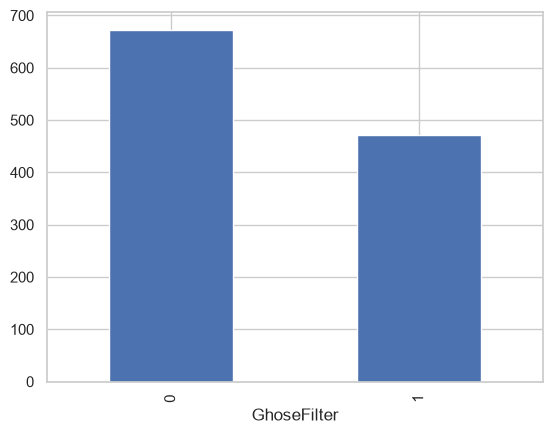

In [25]:
gf = data['GhoseFilter'].astype(int)
gf.value_counts().plot(kind='bar')


In [26]:
data = data[column_num + column_bool]

In [27]:
data.shape

(1144, 1286)

In [28]:
def remove_constant_values(data):
    return [e for e in data.columns if data[e].nunique() == 1]

drop_col = remove_constant_values(data)
#drop_col

new_df_columns = [e for e in data.columns if e not in drop_col]
new_df = data[new_df_columns]
new_df

ABC      ABCGG  nBase    SpAbs_A   SpMax_A  SpDiam_A     SpAD_A  \
0      4.012290   4.284816      0   5.818626  2.074313  4.148627   5.818626   
1      3.464102   3.464102      0   4.000000  2.000000  4.000000   4.000000   
2      3.932653   4.244375      0   6.000000  2.000000  4.000000   6.000000   
3      3.047207   3.305183      0   5.226252  1.847759  3.695518   5.226252   
4      5.808525   6.167293      0   7.211103  2.302776  4.605551   7.211103   
...         ...        ...    ...        ...       ...       ...        ...   
1139  10.943860  10.834541      0  19.178732  2.222674  4.445348  19.178732   
1140  13.848577  12.817957      0  21.491177  2.513161  4.873236  21.491177   
1141  17.872588  14.857897      0  29.447228  2.482065  4.964130  29.447228   
1142  17.730457  15.492423      0  27.142711  2.437677  4.875353  27.142711   
1143   9.520558   8.873882      0  15.211804  2.278414  4.556827  15.211804   

       SpMAD_A   LogEE_A     VE1_A     VE2_A     VE3_A       VR1_A     VR2_A  \
0     0.969771  2.626363  2.285500  0.380917  0.315759   11.637367  1.939561   
1     0.800000  2.444466  2.121320  0.424264  0.058892    8.000000  1.600000   
2     1.000000  2.610845  2.309401  0.384900  0.326163   11.530010  1.921668   
3     1.045250  2.408576  2.130986  0.426197  0.063438    8.629874  1.725975   
4     0.901388  2.947233  2.602595  0.325324  0.733365   17.881697  2.235212   
...        ...       ...       ...       ...       ...         ...       ...   
1139  1.198671  3.613477  3.333258  0.208329  1.673954   92.824702  5.801544   
1140  1.193954  3.821470  3.668785  0.203821  1.887647  105.790793  5.877266   
1141  1.280314  4.064996  4.121171  0.179181  2.249046  175.486940  7.629867   
1142  1.180118  4.049881  4.179173  0.181703  2.263023  152.094429  6.612801   
1143  1.170139  3.450538  3.265105  0.251162  1.445656   57.381559  4.413966   

      nAromAtom  nAromBond  nAtom  nHeavyAtom  nSpiro  nBridgehead  nHetero  \
0             0          0      8           6       0            0        4   
1             0          0      8           5       0            0        3   
2             0          0      8           6       0            0        4   
3             0          0      8           5       0            0        3   
4             0          0      8           8       0            0        6   
...         ...        ...    ...         ...     ...          ...      ...   
1139          0          0     34          16       0            0        8   
1140          6          6     27          18       0            0        6   
1141         16         17     39          23       0            0        4   
1142         12         12     38          23       0            0        8   
1143          6          6     26          13       0            0        3   

      nH  nC  nN  nO  nS  nP  nF  nCl  nBr  nI  nX      ATS0dv      ATS1dv  \
0      2   2   0   0   0   0   0    4    0   0   4   22.419753   18.888889   
1      3   2   0   0   0   0   0    3    0   0   3   18.814815   13.333333   
2      2   2   0   0   0   0   0    4    0   0   4   20.419753   18.333333   
3      3   2   0   0   0   0   0    3    0   0   3   14.814815   12.222222   
4      0   2   0   0   0   0   3    3    0   0   6  180.814815  109.333333   
...   ..  ..  ..  ..  ..  ..  ..  ...  ...  ..  ..         ...         ...   
1139  18   8   1   4   2   1   0    0    0   0   0  198.197531   90.037037   
1140   9  12   1   3   0   0   0    2    0   0   2  271.209877  272.222222   
1141  16  19   0   4   0   0   0    0    0   0   0  340.000000  333.000000   
1142  15  15   2   4   1   0   0    1    0   0   1  334.049383  269.777778   
1143  13  10   1   2   0   0   0    0    0   0   0  182.000000  172.000000   

          ATS2dv      ATS3dv      ATS4dv      ATS5dv      ATS6dv      ATS7dv  \
0       9.592593    1.814815    0.000000    0.000000    0.000000    0.000000   
1       4.148148    0.000000    0.000000    0.000000    

In [29]:
len(drop_col)

154

In [30]:

def correlation(dataset, threshold):
    col_corr = set()  
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]  
                col_corr.add(colname)
    return col_corr

In [31]:

corr_features = correlation(new_df, 0.80)
print("No. of features to drop : ",len(set(corr_features)))

new_df.drop(corr_features,axis=1,inplace=True)

No. of features to drop :  849


In [32]:
new_df.shape

(1144, 283)

In [33]:
new_df.head()

,ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor18,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor25m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,4.012290,0,0.969771,11.637367,0,0,0,4,0,0,0,0,0,4,0,0,1230,2.802469,153.75,9.602557,162.007716,-0.011568,0.0,0.0,0.0,0.0,0.0,-2.908179,-5.972222,2.858796,0.0,0.0,0.0,0.0,0.0,-3.0000,2.250000,0.0,0.0,0.0,0.0,0.0,-18.0625,61.25,-237.9375,0.0,0.0,0.0,0.0,0.0,-7.930847,84.336362,-276.801627,0.0,0.0,0.0,0.0,0.0,-0.106276,-0.673413,0.0,0.0,0.0,0.0,0.0,-0.000018,-2.068421,-2.625254,1.670496,0.0,0.0,0.0,0.0,-0.464286,5.104167,50.099028,0.755795,-0.503243,-0.052998,0.104835,0.953397,0.685494,0.783269,0.752253,0.821321,0.822885,1.128276,-0.188915,0.766179,4.017023,0.986612,5.897854,3.168490,0,0,0.007215,0.330754,0.551252,183.478709,0.000000,0,0,0,2,0,0,0,1.0,0.0,0.0,0.353553,0.515432,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.941684,0.426777,0.0,-3.50,0.587894,0,1.500000,1.750000,0.500000,0.583333,-2.790326,0.004709,0.519616,0.407676,0.135076,0.051115,-0.389769,-0.105027,0.450105,0.177455,-0.120264,-0.251743,-0.106741,-0.091505,0.037270,0.030745,-0.075668,-0.136317,0.166454,0.003512,9.423595,1.305930,2.964078,0.545951,-0.044652,-0.236744,-0.540972,1.434142,-1.375101,0.659696,-0.315739,0.691005,-1.079840,0.763771,-0.102885,-0.017743,-0.413645,0.592649,-0.206470,-0.188544,0.121392,0.109337,0.014802,-0.382249,0.483602,-0.290140,0.224230,-0.048445,-0.022037,-0.140933,-0.054703,0.003871,-0.062377,0.0,0.0,0.000000,11.60094,34.80282,0.000000,0.0,5.880003,0.000000,0.000000,3.792536,0.0,5.880003,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,5.880003,0.000000,0.0,0.000000,0.0,0.0,0.00000,-1.276235,0.0,0.039352,0.0,0.0,0.605060,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.600000,0.095238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False
1,3.464102,0,0.800000,8.000000,0,0,0,3,0,0,0,0,0,3,0,0,942,2.351852,117.75,8.932912,164.102494,0.043231,0.0,0.0,0.0,0.0,0.0,-1.256944,-5.935185,1.145833,0.0,0.0,0.0,0.0,0.0,-1.6875,1.265625,0.0,0.0,0.

In [34]:
new_df['Lipinski'] = df["Lipinski"].astype(int)
new_df['GhoseFilter'] = df["GhoseFilter"].astype(int)

In [ ]:
new_df.head()

In [35]:
df_final = pd.concat([df.iloc[:, :3], new_df], axis=1)
df_final.head()

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor18,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor25m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,"1,1,1,2-Tetrachloroethane",ClCC(Cl)(Cl)Cl,-2.18,4.012290,0,0.969771,11.637367,0,0,0,4,0,0,0,0,0,4,0,0,1230,2.802469,153.75,9.602557,162.007716,-0.011568,0.0,0.0,0.0,0.0,0.0,-2.908179,-5.972222,2.858796,0.0,0.0,0.0,0.0,0.0,-3.0000,2.250000,0.0,0.0,0.0,0.0,0.0,-18.0625,61.25,-237.9375,0.0,0.0,0.0,0.0,0.0,-7.930847,84.336362,-276.801627,0.0,0.0,0.0,0.0,0.0,-0.106276,-0.673413,0.0,0.0,0.0,0.0,0.0,-0.000018,-2.068421,-2.625254,1.670496,0.0,0.0,0.0,0.0,-0.464286,5.104167,50.099028,0.755795,-0.503243,-0.052998,0.104835,0.953397,0.685494,0.783269,0.752253,0.821321,0.822885,1.128276,-0.188915,0.766179,4.017023,0.986612,5.897854,3.168490,0,0,0.007215,0.330754,0.551252,183.478709,0.000000,0,0,0,2,0,0,0,1.0,0.0,0.0,0.353553,0.515432,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.941684,0.426777,0.0,-3.50,0.587894,0,1.500000,1.750000,0.500000,0.583333,-2.790326,0.004709,0.519616,0.407676,0.135076,0.051115,-0.389769,-0.105027,0.450105,0.177455,-0.120264,-0.251743,-0.106741,-0.091505,0.037270,0.030745,-0.075668,-0.136317,0.166454,0.003512,9.423595,1.305930,2.964078,0.545951,-0.044652,-0.236744,-0.540972,1.434142,-1.375101,0.659696,-0.315739,0.691005,-1.079840,0.763771,-0.102885,-0.017743,-0.413645,0.592649,-0.206470,-0.188544,0.121392,0.109337,0.014802,-0.382249,0.483602,-0.290140,0.224230,-0.048445,-0.022037,-0.140933,-0.054703,0.003871,-0.062377,0.0,0.0,0.000000,11.60094,34.80282,0.000000,0.0,5.880003,0.000000,0.000000,3.792536,0.0,5.880003,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,5.880003,0.000000,0.0,0.000000,0.0,0.0,0.00000,-1.276235,0.0,0.039352,0.0,0.0,0.605060,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.600000,0.095238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,"1,1,1-Trichloroethane",CC(Cl)(Cl)Cl,-2.00,3.464102,0,0.800000,8.000000,0,0,0,3,0,0,0,0,0,3,0,0,942,2.3518

In [ ]:
df_final.shape

In [ ]:
df_final.to_csv('delaney_mordred_truncated.csv', index=None)

## **Data Analysis**

In [36]:
df_final['measured log(solubility:mol/L)'].describe()

count    1144.000000
mean       -3.057997
std         2.096502
min       -11.600000
25%        -4.332250
50%        -2.870500
75%        -1.600000
max         1.580000
Name: measured log(solubility:mol/L), dtype: float64

(array([  1.,   4.,  33.,  48.,  99., 210., 288., 269., 137.,  55.]),
 array([-11.6  , -10.282,  -8.964,  -7.646,  -6.328,  -5.01 ,  -3.692,
         -2.374,  -1.056,   0.262,   1.58 ]),
 <BarContainer object of 10 artists>)

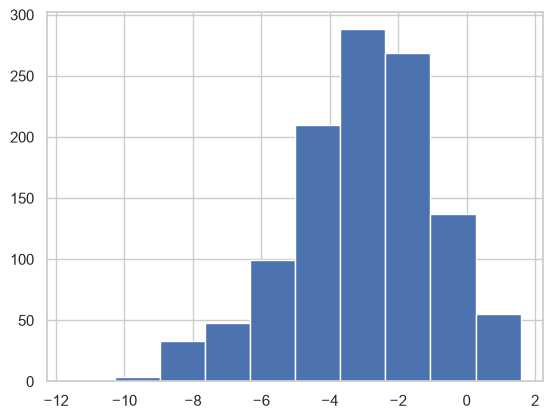

In [37]:
plt.hist(df_final['measured log(solubility:mol/L)'])

In [38]:
df_final = df_final.iloc[:, 2:]

In [39]:
corr = df_final.corr()
corr

,measured log(solubility:mol/L),ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor18,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor25m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
measured log(solubility:mol/L),1.000000,-0.587292,0.009436,-0.400888,-0.042746,-0.489810,0.009736,-0.095359,-0.179433,0.066841,0.059156,-0.061972,-0.081202,-0.127937,-0.399321,-0.035298,-0.017184,-0.459590,-0.044767,-0.075770,-0.000651,0.484488,-0.007366,-0.022459,0.033025,-0.005921,-0.063347,0.055003,-0.251400,-0.136296,-0.069324,0.045084,0.100243,0.113411,0.091624,0.086496,-0.083580,0.157898,0.234003,0.224319,0.173496,0.023859,-0.043903,-0.172014,-0.140773,-0.002663,0.082909,0.116975,0.203553,-0.006384,0.097382,-0.235124,-0.060179,-0.076672,0.100385,0.139165,0.186926,0.060701,0.013337,-0.153374,0.000660,0.027871,0.055575,-0.001550,0.006709,0.137679,-0.149955,-0.095963,-0.048922,0.051971,0.123415,0.081283,0.018429,0.019280,-0.211371,-0.077118,-0.021490,-0.032876,-0.196674,-0.251458,-0.109734,-0.070623,0.218447,0.203393,0.251753,0.120214,0.070777,0.180441,0.072270,0.140584,-0.280094,-0.140636,0.480060,0.253453,-0.061760,-0.035014,0.405784,0.627965,0.465201,-0.436564,-0.137571,-0.016924,0.099221,-0.518606,-0.020546,-0.162640,-0.216889,-0.123942,0.232514,-0.097353,-0.159150,-0.156156,-0.075765,-0.011673,0.071495,0.005334,-0.028907,-0.063551,-0.483985,-0.289508,0.133202,0.015074,0.029107,0.048935,-0.038680,-0.017509,0.081737,-0.093514,-0.022719,0.062146,0.177421,-0.055227,-0.030371,0.031218,-0.107818,-0.037076,0.019996,0.024952,-0.010519,-0.117250,-0.055631,-0.327980,-0.284784,-0.364286,-0.317189,-0.135497,0.384331,-0.110615,-0.252825,0.218084,0.083560,-0.071464,0.358809,0.251673,0.863686,-0.256223,0.231649,0.030888,0.211875,0.073441,-0.067450,0.201688,-0.111789,-0.225766,0.029718,0.445396,-0.104401,0.069254,-0.046681,0.414961,0.095509,0.116262,-0.079371,0.390405,-0.279379,0.100528,-0.438404,0.027714,0.046527,-0.242614,-0.168484,0.183573,0.228162,-0.392165,0.038414,-0.198214,0.483117,0.150631,-0.557554,0.388698,-0.039628,0.12879

In [40]:
corr_sorted = abs(corr[['measured log(solubility:mol/L)']]).sort_values(by ='measured log(solubility:mol/L)', ascending=False)
corr_sorted = corr_sorted.iloc[1:5, :]
corr_sorted.rename(columns={'measured log(solubility:mol/L)' : 'correlation_coef'}, inplace=True)
corr_sorted

,correlation_coef
FilterItLogS,0.863686
PEOE_VSA6,0.705928
RNCG,0.627965
ABC,0.587292


Text(0, 0.5, 'Correlation Coefficient')

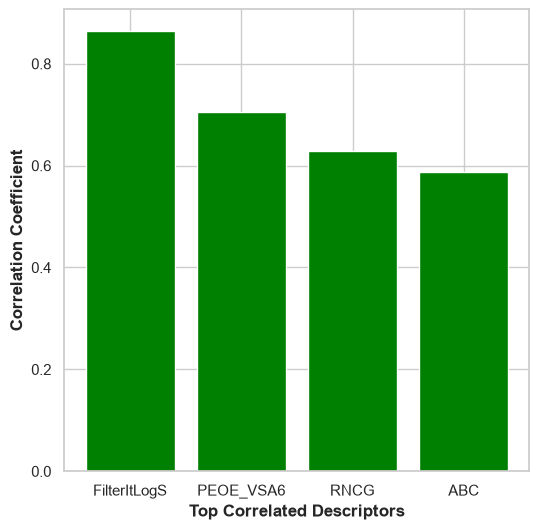

In [41]:
fig = plt.figure(1, figsize=(6,6))
ax1 = fig.add_subplot(111)
plt.bar(x = corr_sorted.index, height = corr_sorted['correlation_coef'], color = 'green')
ax1.set_xlabel('Top Correlated Descriptors', weight='bold')
ax1.set_ylabel('Correlation Coefficient', weight='bold')

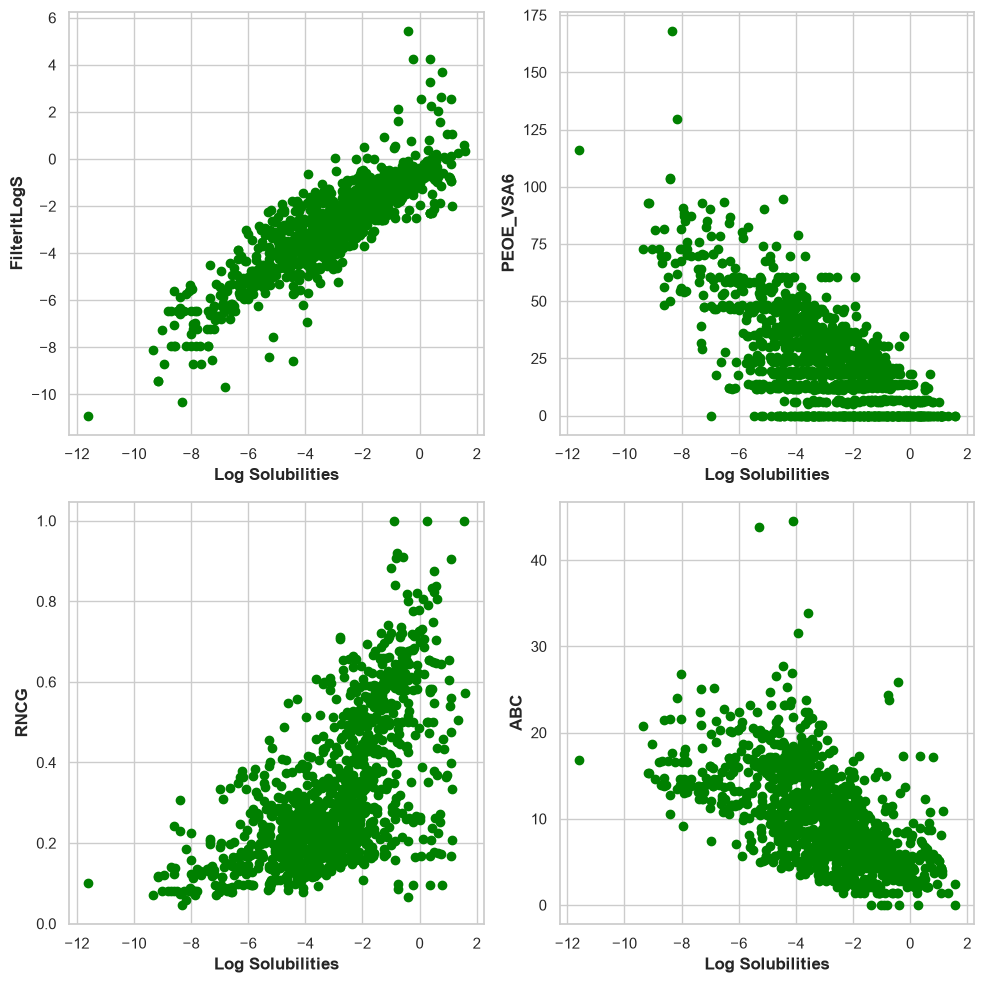

In [42]:
fig = plt.figure(4, figsize=(10,10))
ax = fig.add_subplot(221)
plt.scatter(x = df_final['measured log(solubility:mol/L)'], y = df_final['FilterItLogS'], color = 'green')
ax.set_xlabel('Log Solubilities', weight='bold')
ax.set_ylabel('FilterItLogS', weight='bold')

ax = fig.add_subplot(222)
plt.scatter(x = df_final['measured log(solubility:mol/L)'], y = df_final['PEOE_VSA6'], color = 'green')
ax.set_xlabel('Log Solubilities', weight='bold')
ax.set_ylabel('PEOE_VSA6', weight='bold')

ax = fig.add_subplot(223)
plt.scatter(x = df_final['measured log(solubility:mol/L)'], y = df_final['RNCG'], color = 'green')
ax.set_xlabel('Log Solubilities', weight='bold')
ax.set_ylabel('RNCG', weight='bold')

ax = fig.add_subplot(224)
plt.scatter(x = df_final['measured log(solubility:mol/L)'], y = df_final['ABC'], color = 'green')
ax.set_xlabel('Log Solubilities', weight='bold')
ax.set_ylabel('ABC', weight='bold')
plt.tight_layout()

In [43]:
df_final = pd.read_csv(r"C:\Users\pc\Desktop\project\tutorial_rdkit\delaney_mordred_truncated.csv")

## **Building Machine Learning Model**

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [45]:
df_final = pd.read_csv(r"C:\Users\pc\Desktop\project\tutorial_rdkit\delaney_mordred_truncated.csv")


In [46]:
df_final.head()

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,"1,1,1,2-Tetrachloroethane",ClCC(Cl)(Cl)Cl,-2.18,4.012290,0,0.969771,11.637367,0,0,0,4,0,0,0,0,0,4,0,0,1230,2.802469,153.75,9.602557,162.007716,-0.011568,0.0,0.0,0.0,0.0,0.0,-2.908179,-5.972222,2.858796,0.0,0.0,0.0,0.0,0.0,-3.0000,2.250000,0.0,0.0,0.0,0.0,0.0,-18.0625,61.25,-237.9375,0.0,0.0,0.0,0.0,0.0,-7.930847,84.336362,-276.801627,0.0,0.0,0.0,0.0,0.0,-0.106276,-0.673413,0.0,0.0,0.0,0.0,0.0,-0.000018,-2.068421,-2.625254,1.670496,0.0,0.0,0.0,0.0,-0.464286,5.104167,50.099028,0.755795,-0.503243,-0.052998,0.104835,0.953397,0.685494,0.783269,0.752253,0.821321,0.822885,1.128276,-0.188915,0.766179,4.017023,0.986612,5.897854,3.168490,0,0,0.007122,0.330754,0.551252,183.331218,0.000000,0,0,0,2,0,0,0,1.0,0.0,0.0,0.353553,0.515432,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,0.000000,0.0,0.941684,0.426777,0.0,-3.50,0.587931,0,1.500000,1.750000,0.500000,0.583333,-2.790326,0.006067,0.523051,0.419031,0.126253,0.052579,-0.396607,-0.088052,0.436703,0.176355,-0.121027,-0.111853,-0.109321,0.030779,0.031542,-0.077838,-0.135739,0.176945,0.006169,9.368045,1.294557,2.961506,0.482696,0.013874,-0.310771,-0.444708,1.341090,-1.309609,0.614539,-0.271620,0.652980,-1.073352,0.796019,-0.150769,0.028099,-0.470898,0.678911,-0.308817,0.054015,0.174031,-0.055465,-0.327701,0.465231,-0.295556,0.227792,-0.047366,-0.017921,-0.149382,-0.072866,-0.002447,-0.072585,0.0,0.0,0.000000,11.60094,34.80282,0.000000,0.0,5.880003,0.000000,0.000000,3.792536,0.0,5.880003,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,5.880003,0.000000,0.0,0.000000,0.0,0.0,0.00000,-1.276235,0.0,0.039352,0.0,0.0,0.604444,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.600000,0.095238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,"1,1,1-Trichloroethane",CC(Cl)(Cl)Cl,-2.00,3.464102,0,0.800000,8.000000,0,0,0,3,0,0,0,0,0,3,0,0,942,2.351852,117.75,8.932912,164.102494,0.0

In [47]:
df_final.shape

(1144, 284)

In [48]:
y = df_final['measured log(solubility:mol/L)']

In [49]:
scaled_DF = pd.DataFrame(StandardScaler().fit_transform(df_final.iloc[:,3:]))
scaled_DF.columns = df_final.iloc[: , 3:].columns


**Standerscaler for how the features away from the mean**

In [50]:
scaled_DF

,ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,nS,nP,nF,nCl,nBr,nI,ATS0Z,AATS0dv,AATS0Z,AATS0se,AATS0i,ATSC2c,ATSC4c,ATSC5c,ATSC6c,ATSC7c,ATSC8c,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC1se,ATSC3se,ATSC4se,ATSC5se,ATSC6se,ATSC7se,ATSC8se,ATSC1p,ATSC1i,ATSC2i,ATSC3i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC1d,AATSC2Z,AATSC0v,AATSC0i,MATS1c,MATS1Z,MATS2Z,GATS2c,GATS1Z,GATS2Z,GATS2v,GATS1se,GATS2se,GATS2i,BCUTc-1l,BCUTdv-1l,BCUTd-1h,BCUTd-1l,BCUTZ-1l,BalabanJ,nBondsD,nBondsT,FPSA3,RNCG,RPCG,RNCS,RPCS,C2SP1,C1SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xc-4d,Xc-4dv,NsCH3,NdCH2,NtCH,NdsCH,NsssCH,NaasC,NaaaC,NsNH2,NdNH,NssNH,NaaNH,NtN,NdsN,NaaN,NsssN,NddsN,NaasN,NsOH,NssO,NaaO,NsSH,NdS,NssS,NaaS,NdssS,NddssS,SsssCH,SdssC,SaasC,ETA_shape_y,ETA_beta_ns_d,AETA_eta,AETA_eta_RL,ETA_dEpsilon_D,ETA_dBeta,GeomShapeIndex,nHBDon,IC0,IC1,SIC0,SIC1,FilterItLogS,Mor04,Mor06,Mor08,Mor09,Mor10,Mor11,Mor12,Mor13,Mor15,Mor16,Mor22,Mor24,Mor26,Mor27,Mor28,Mor29,Mor30,Mor32,Mor02m,Mor04m,Mor06m,Mor09m,Mor10m,Mor11m,Mor12m,Mor13m,Mor14m,Mor15m,Mor16m,Mor17m,Mor18m,Mor19m,Mor20m,Mor21m,Mor22m,Mor23m,Mor24m,Mor26m,Mor27m,Mor28m,Mor29m,Mor30m,Mor31m,Mor32m,Mor04v,Mor10v,Mor11v,Mor24v,Mor26v,Mor28v,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA6,SMR_VSA9,SlogP_VSA1,SlogP_VSA3,SlogP_VSA4,SlogP_VSA7,SlogP_VSA10,SlogP_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,VSA_EState1,VSA_EState4,VSA_EState5,VSA_EState9,AMID_O,PBF,n5Ring,n7Ring,n8Ring,nHRing,n3HRing,n5HRing,n5aRing,nAHRing,n5AHRing,n6AHRing,nFRing,n6FRing,n7FRing,n8FRing,n9FRing,n10FRing,n11FRing,n12FRing,nG12FRing,nFHRing,n10FHRing,n12FHRing,nG12FHRing,n9FaRing,nFaHRing,nG12FaHRing,nFARing,n9FARing,n10FARing,nFAHRing,n10FAHRing,nRot,JGI1,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,-1.046794,-0.077041,-2.070914,-0.054329,-0.998199,-0.083918,-0.115751,0.221643,-0.665609,-0.840065,-0.298585,-0.193594,-0.181742,2.379965,-0.187084,-0.114199,0.534794,-1.042162,1.535119,2.670631,-0.077580,-0.360705,-0.057855,0.161615,-0.102974,0.019823,-0.012392,-1.022601,-0.510354,0.476465,0.644625,0.483949,0.248957,0.183877,0.058433,-0.388459,0.941355,0.639348,0.346063,0.229275,0.066487,-0.107053,-0.525399,0.354026,-1.177689,0.360401,0.309065,0.190293,0.111369,0.102574,-0.004953,0.171353,-0.141929,0.422702,0.316696,0.148690,0.125660,0.008296,-0.005248,-0.618896,0.322006,0.404415,0.030341,0.119375,0.149583,0.088788,0.113721,-0.230600,0.775508,0.115421,0.025327,0.029601,0.037571,-3.540486,0.572873,0.093324,-1.281334,-0.243078,-0.507734,0.528135,0.082791,-0.515588,-0.323627,-0.995501,-0.034866,0.096912,0.193974,1.855615,-0.521459,1.319652,-0.194121,2.082559,1.625369,-0.806785,-0.183727,-1.727055,0.033750,3.187876,0.780952,-1.039845,-0.114199,-0.619746,-0.594911,0.208391,-0.573663,-0.391650,-0.330012,1.487506,-0.119157,-0.119479,2.320818,1.867525,-0.999748,-0.194396,-0.112199,-0.342726,-0.408387,-0.829287,-0.288676,-0.260465,-0.029579,-0.419402,-0.15008,-0.135319,-0.125144,-0.320346,-0.336726,-0.213785,-0.169674,-0.366692,-0.455118,-0.141749,-0.066256,-0.19552,-0.207568,-0.098533,-0.059235,-0.147007,0.095239,0.092668,-0.583633,-1.809236,-0.659624,0.647550,-2.211873,-0.627356,-0.559788,-1.070634,-0.639902,0.237187,-1.060678,1.784579,0.203700,0.021772,-0.404568,1.596510,-0.491970,0.261738,0.941061,-0.028687,0.766443,0.053245,-0.177753,-0.384009,-0.159642,0.143175,-1.088096,1.292525,0.469336,0.228322,0.126345,0.696699,-0.354985,1.298173,1.105318,1.390009,-0.316967,-0.973713,-1.334246,2.912183,-1.370449,-0.025292,-0.562599,2.003144,-2.156426,1.932497,-1.277584,0.754970,-1.816106,2.561972,-1.369912,0.768058,0.758897,-0.330012,-1.556439,2.050058,-1.741282,1.373635,0.311617,-

In [51]:
X_train, X_test, y_train, y_test = train_test_split(scaled_DF, y, test_size=0.20, random_state=45)

In [52]:
X_test.shape

(229, 281)

**$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p$$**
sm.statsmodel is used to be beta_0 diffrent to 0 in this equation system(Linear_regression)


In [53]:

x = sm.add_constant(X_train)
results = sm.OLS(y_train, x).fit()
print(results.summary())

C:\Users\pc\AppData\Local\Temp\ipykernel_20252\1220415530.py:2: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results = sm.OLS(y_train, x).fit()


                                  OLS Regression Results                                  
Dep. Variable:     measured log(solubility:mol/L)   R-squared:                       0.953
Model:                                        OLS   Adj. R-squared:                  0.933
Method:                             Least Squares   F-statistic:                     47.45
Date:                            Mon, 14 Sep 2026   Prob (F-statistic):          9.20e-310
Time:                                    20:02:18   Log-Likelihood:                -581.91
No. Observations:                             915   AIC:                             1710.
Df Residuals:                                 642   BIC:                             3025.
Df Model:                                     272                                         
Covariance Type:                        nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------

In [54]:
# multiple linear regression model using scikitlearn
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](281,)","[ 1.97, 0.03, 0.17,...,-0.07, 0.09,-0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](281,)","['ABC','nBase','SpMAD_A',...,'JGI10','Lipinski','GhoseFilter']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.044
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,281
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(272)


**clear sign of overfiting is the diminution in the score test by 33%**

In [55]:
print(f'The r2 score for train set is : {lr.score(X_train, y_train)}')
print(f'The r2 score for test set is : {lr.score(X_test, y_test)}')

The r2 score for train set is : 0.9526138008130901
The r2 score for test set is : 0.6235904754965391


In [56]:
y_hat_train = lr.predict(X_train)
y_hat_test = lr.predict(X_test)

In [57]:
r2_score(y_train, y_hat_train)

0.9526138008130901

In [58]:
r2_score(y_test, y_hat_test)

0.6235904754965391

In [59]:
y_hat_train.shape

(915,)

In [60]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [61]:
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')

The r2 score for train set is : 0.9844635274963239
The r2 score for test set is : 0.8680144305303252


## **Cross-Validation**

In [ ]:
val = cross_val_score(rf, X_train, y_train,  scoring='r2', cv=5)

In [ ]:
val.mean()

## **Visualizing the Results**

In [ ]:
plt.scatter(y_test, rf.predict(X_test), label='Test')
sns.regplot(x = y_train, y = rf.predict(X_train), color = 'maroon',scatter_kws={'alpha':0.3}, label='Train' )
plt.xlabel('Measured Solubilities')
plt.ylabel('Predicted Solubilites')
plt.legend();

## **Screen Models using Lazypredict**

In [ ]:
%%capture
!pip install lazypredict

In [ ]:
from lazypredict.Supervised import LazyRegressor

In [ ]:
reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

print(predictions)

## **Dimensionality Reduction Techniques**

# **Principal Component Analysis**

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
scaled_DF.head()

In [ ]:
scaled_DF.shape


In [ ]:
pca = PCA(n_components=8)
pc = pca.fit_transform(scaled_DF)
pc_df = pd.DataFrame(data = pc)

In [ ]:
pc_df.head()

In [ ]:
pca.explained_variance_ratio_

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(pc_df, y, test_size=0.20, random_state=45)

In [ ]:
x = sm.add_constant(X_train)
results = sm.OLS(y_train, x).fit()
print(results.summary())

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f'The r2 score for train set is : {lr.score(X_train, y_train)}')
print(f'The r2 score for test set is : {lr.score(X_test, y_test)}')

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')

# **t-SNE**

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tsne = TSNE(n_components=2)
ts = tsne.fit_transform(scaled_DF)
tsne_df = pd.DataFrame(data = ts)


In [ ]:
tsne_df.head()

**Visuaization in Lower Dimensions**

In [ ]:
y.median()

In [ ]:
sol_cls = [int(boolean) for boolean in list(map(lambda s: s>-2.8, y))]

In [ ]:
from collections import Counter
Counter(sol_cls)

In [ ]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(tsne_df.iloc[:,0],tsne_df.iloc[:,1],
                      c = sol_cls,cmap='plasma'
                      )
plt.legend(handles=scatter.legend_elements()[0], labels=['More Soluble', 'Less Soluble'], loc = 1)
plt.xlabel('tsne Component 1')
plt.ylabel('tsne Component 2')